## ML Training Pipeline: BBB Permeability Classification
Clean, modular pipeline for comparing imbalance-handling strategies across multiple models and split ratios.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
#warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Utility Functions

In [5]:
def load_split(split_ratio: str, base_dir: str = '../data/split'):
    """
    Load train/test split from CSV files.
    split_ratio: '7030', '8020', or '6040'
    """
    base_path = Path(base_dir) / split_ratio
    
    X_train = pd.read_csv(base_path / 'x_train.csv', index_col=0)
    y_train = pd.read_csv(base_path / 'y_train.csv', index_col=0).iloc[:, 0]
    X_test = pd.read_csv(base_path / 'x_test.csv', index_col=0)
    y_test = pd.read_csv(base_path / 'y_test.csv', index_col=0).iloc[:, 0]
    
    # Keep numeric features only
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])
    
    return X_train, y_train, X_test, y_test


def apply_balancing_strategy(X_train, y_train, strategy: str):
    """
    Apply balancing only to training set. Return resampled or original data.
    Strategies: 'raw', 'undersample', 'smote', 'weighted'
    """
    if strategy == 'raw':
        return X_train, y_train, None
    
    if strategy == 'undersample':
        sampler = RandomUnderSampler(random_state=42)
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        return X_res, y_res, None
    
    if strategy == 'smote':
        smote = SMOTE(random_state=42, k_neighbors=5)
        X_res, y_res = smote.fit_resample(X_train, y_train)
        return X_res, y_res, None
    
    if strategy == 'weighted':
        return X_train, y_train, 'balanced'
    
    raise ValueError(f'Unknown strategy: {strategy}')


def get_model(model_name: str, class_weight=None):
    """
    Initialize model. class_weight applies only to certain models.
    """
    models = {
        'LogReg': LogisticRegression(
            max_iter=5000, solver='lbfgs', random_state=42,
            class_weight=class_weight
        ),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'RF': RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=42,
            class_weight=class_weight
        ),
        'ET': ExtraTreesClassifier(
            n_estimators=100, max_depth=10, random_state=42,
            class_weight=class_weight
        ),
        'XGB': XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42,
            scale_pos_weight=None if class_weight != 'balanced' else None
        ),
        'LGBM': LGBMClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42,
            is_unbalanced=class_weight == 'balanced' if class_weight else False
        )
    }
    return models[model_name]


def compute_metrics(y_true, y_pred, y_proba=None):
    """
    Compute all evaluation metrics.
    """
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        specificity = np.nan
    
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'specificity': specificity,
        'mcc': matthews_corrcoef(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    }
    return metrics


def train_and_evaluate(model_name, X_train, y_train, X_test, y_test, strategy):
    """
    Train model with given strategy and evaluate on test set.
    """
    # Apply balancing
    X_res, y_res, class_weight = apply_balancing_strategy(X_train, y_train, strategy)
    
    # Initialize model
    model = get_model(model_name, class_weight=class_weight)
    
    # Scale and train - scales all models (doesn't affect tree based models much)
    scaler = StandardScaler()
    X_res_scaled = scaler.fit_transform(X_res)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_res_scaled, y_res)
    y_pred = model.predict(X_test_scaled)
    
    # Get probabilities if available
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = None
    
    metrics = compute_metrics(y_test, y_pred, y_proba)
    metrics['train_n'] = X_res.shape[0]
    metrics['train_pos'] = (y_res == 1).sum()
    metrics['train_neg'] = (y_res == 0).sum()
    
    return metrics


print('Utility functions defined.')

Utility functions defined.


### Experiment Runner: 70/30 Split

In [6]:
# Load 70/30 split
X_train, y_train, X_test, y_test = load_split('7030')

print(f"7030 Split loaded:")
print(f"  Train: {X_train.shape[0]} samples ({(y_train==1).sum()} pos, {(y_train==0).sum()} neg)")
print(f"  Test:  {X_test.shape[0]} samples ({(y_test==1).sum()} pos, {(y_test==0).sum()} neg)")
print(f"  Features: {X_train.shape[1]}")


7030 Split loaded:
  Train: 6624 samples (4700 pos, 1924 neg)
  Test:  2839 samples (2015 pos, 824 neg)
  Features: 933


In [7]:
# Run all experiments on 70/30
models = ['LogReg', 'KNN', 'RF', 'ET', 'XGB', 'LGBM']
strategies = ['raw', 'undersample', 'smote', 'weighted']

results_7030 = []

for model_name in models:
    for strategy in strategies:
        print(f'Training {model_name:6} with {strategy:12}... ', end='', flush=True)
        metrics = train_and_evaluate(model_name, X_train, y_train, X_test, y_test, strategy)
        metrics['model'] = model_name
        metrics['strategy'] = strategy
        metrics['split'] = '7030'
        results_7030.append(metrics)
        print('done')

df_7030 = pd.DataFrame(results_7030)
print(f"\nCompleted {len(df_7030)} experiments on 70/30 split.")


Training LogReg with raw         ... done
Training LogReg with undersample ... done
Training LogReg with smote       ... done
Training LogReg with weighted    ... done
Training KNN    with raw         ... done
Training KNN    with undersample ... done
Training KNN    with smote       ... done
Training KNN    with weighted    ... done
Training RF     with raw         ... done
Training RF     with undersample ... done
Training RF     with smote       ... done
Training RF     with weighted    ... done
Training ET     with raw         ... done
Training ET     with undersample ... done
Training ET     with smote       ... done
Training ET     with weighted    ... done
Training XGB    with raw         ... done
Training XGB    with undersample ... done
Training XGB    with smote       ... done
Training XGB    with weighted    ... done
Training LGBM   with raw         ... [LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Inf

### Results: 70/30 Split

In [8]:
# Display results sorted by key metrics
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display_cols = ['model', 'strategy', 'accuracy', 'balanced_accuracy', 'f1', 'mcc', 'recall', 'specificity', 'roc_auc']
df_display = df_7030[display_cols].copy()
df_display = df_display.sort_values(by=['model', 'balanced_accuracy'], ascending=[True, False])

print("\n" + "="*120)
print("RESULTS: 70/30 SPLIT - ALL MODELS AND STRATEGIES")
print("="*120)
display(df_display)



RESULTS: 70/30 SPLIT - ALL MODELS AND STRATEGIES


,model,strategy,accuracy,balanced_accuracy,f1,mcc,recall,specificity,roc_auc
13,ET,undersample,0.831631,0.824722,0.876422,0.619108,0.841191,0.808252,0.891719
15,ET,weighted,0.839732,0.818235,0.885072,0.621754,0.869479,0.766990,0.896589
14,ET,smote,0.834097,0.815699,0.880305,0.612486,0.859553,0.771845,0.891249
12,ET,raw,0.822473,0.752277,0.880285,0.546826,0.919603,0.584951,0.894710
5,KNN,undersample,0.813667,0.815653,0.860679,0.592721,0.810918,0.820388,0.870278
6,KNN,smote,0.814371,0.813639,0.861789,0.590800,0.815385,0.811893,0.870194
4,KNN,raw,0.817189,0.764695,0.873569,0.545208,0.889826,0.639563,0.866808
7,KNN,weighted,0.817189,0.764695,0.873569,0.545208,0.889826,0.639563,0.866808
21,LGBM,undersample,0.836210,0.843728,0.877406,0.644946,0.825806,0.861650,0.897980
22,LGBM,smote,0.843607,0.819171,0.888442,0.627650,0.877419,0.760922,0.903729


In [9]:
# Summary: Best strategy per model on 70/30
print("\n" + "="*100)
print("BEST STRATEGY PER MODEL (70/30 split) - Based on Balanced Accuracy")
print("="*100)

best_per_model = df_7030.loc[df_7030.groupby('model')['balanced_accuracy'].idxmax()]
best_display = best_per_model[['model', 'strategy', 'accuracy', 'balanced_accuracy', 'f1', 'mcc', 'recall', 'specificity', 'roc_auc']].copy()
best_display = best_display.sort_values('balanced_accuracy', ascending=False)

display(best_display)

# Store best strategies for later use
best_strategies_dict = dict(zip(best_per_model['model'], best_per_model['strategy']))
print(f"\nBest strategies: {best_strategies_dict}")



BEST STRATEGY PER MODEL (70/30 split) - Based on Balanced Accuracy


,model,strategy,accuracy,balanced_accuracy,f1,mcc,recall,specificity,roc_auc
17,XGB,undersample,0.837267,0.844114,0.878357,0.646288,0.827792,0.860437,0.896434
21,LGBM,undersample,0.836210,0.843728,0.877406,0.644946,0.825806,0.861650,0.897980
9,RF,undersample,0.831279,0.834516,0.874311,0.629873,0.826799,0.842233,0.893250
13,ET,undersample,0.831631,0.824722,0.876422,0.619108,0.841191,0.808252,0.891719
5,KNN,undersample,0.813667,0.815653,0.860679,0.592721,0.810918,0.820388,0.870278
3,LogReg,weighted,0.809440,0.810882,0.857444,0.583538,0.807444,0.814320,0.871633



Best strategies: {'ET': 'undersample', 'KNN': 'undersample', 'LGBM': 'undersample', 'LogReg': 'weighted', 'RF': 'undersample', 'XGB': 'undersample'}


### Cross-Split Validation: Apply Best Strategies to 80/20 and 60/40

In [10]:
# Run best strategies on other split ratios
results_other_splits = []

for split_ratio in ['8020', '6040']:
    print(f"\n{'='*70}")
    print(f"Testing best strategies on {split_ratio} split")
    print(f"{'='*70}")
    
    X_train, y_train, X_test, y_test = load_split(split_ratio)
    print(f"Loaded {split_ratio}: Train {X_train.shape[0]}, Test {X_test.shape[0]}")
    
    for model_name, best_strategy in best_strategies_dict.items():
        print(f'  {model_name:6} with {best_strategy:12}... ', end='', flush=True)
        metrics = train_and_evaluate(model_name, X_train, y_train, X_test, y_test, best_strategy)
        metrics['model'] = model_name
        metrics['strategy'] = best_strategy
        metrics['split'] = split_ratio
        results_other_splits.append(metrics)
        print('done')

df_other = pd.DataFrame(results_other_splits)
print(f"\nCompleted {len(df_other)} experiments on 80/20 and 60/40 splits.")



Testing best strategies on 8020 split
Loaded 8020: Train 7570, Test 1893
  ET     with undersample ... done
  KNN    with undersample ... done
  LGBM   with undersample ... [LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Info] Number of positive: 2198, number of negative: 2198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 148998
[LightGBM] [Info] Number of data points in the train set: 4396, number of used features: 719
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [11]:
# Combine all results
df_all_results = pd.concat([df_7030, df_other], ignore_index=True)

print("\n" + "="*100)
print("PERFORMANCE ACROSS ALL SPLITS - BEST STRATEGIES")
print("="*100)

cross_split = df_other[['model', 'split', 'strategy', 'accuracy', 'balanced_accuracy', 'f1', 'mcc', 'roc_auc']].copy()
cross_split = cross_split.sort_values(by=['model', 'split'])

display(cross_split)



PERFORMANCE ACROSS ALL SPLITS - BEST STRATEGIES


,model,split,strategy,accuracy,balanced_accuracy,f1,mcc,roc_auc
6,ET,6040,undersample,0.824617,0.817289,0.871068,0.604095,0.886185
0,ET,8020,undersample,0.840465,0.829592,0.883846,0.633621,0.899484
7,KNN,6040,undersample,0.809297,0.807572,0.857986,0.579327,0.861631
1,KNN,8020,undersample,0.822504,0.819618,0.868545,0.604916,0.882427
8,LGBM,6040,undersample,0.827258,0.831787,0.870904,0.623272,0.889172
2,LGBM,8020,undersample,0.847861,0.851981,0.887059,0.664895,0.907820
9,LogReg,6040,weighted,0.809826,0.811708,0.857651,0.584880,0.871752
3,LogReg,8020,weighted,0.821447,0.816189,0.868175,0.600003,0.879908
10,RF,6040,undersample,0.821447,0.816669,0.868123,0.600453,0.887647
4,RF,8020,undersample,0.845219,0.843678,0.885948,0.653271,0.903996


In [12]:
# Export results to CSV
output_dir = Path('../output/models/sampling_strat')
output_dir.mkdir(parents=True, exist_ok=True)

df_7030.to_csv(output_dir / 'results_7030_all_strategies.csv', index=False)
df_other.to_csv(output_dir / 'results_cross_splits.csv', index=False)
df_all_results.to_csv(output_dir / 'results_all_comprehensive.csv', index=False)
best_per_model.to_csv(output_dir / 'best_strategies_per_model.csv', index=False)

print(f"Results exported to {output_dir}")


Results exported to ../output/models/sampling_strat


### Summary Statistics

In [13]:
# Stability check: variance of best strategy across splits
print("\n" + "="*100)
print("STABILITY CHECK: Variance of Best Strategy Across Splits")
print("="*100)

stability = df_other.groupby('model')[['accuracy', 'balanced_accuracy', 'f1', 'roc_auc']].agg(['mean', 'std'])
print(stability.round(4))



STABILITY CHECK: Variance of Best Strategy Across Splits
       accuracy         balanced_accuracy              f1         roc_auc  \
           mean     std              mean     std    mean     std    mean   
model                                                                       
ET       0.8325  0.0112            0.8234  0.0087  0.8775  0.0090  0.8928   
KNN      0.8159  0.0093            0.8136  0.0085  0.8633  0.0075  0.8720   
LGBM     0.8376  0.0146            0.8419  0.0143  0.8790  0.0114  0.8985   
LogReg   0.8156  0.0082            0.8139  0.0032  0.8629  0.0074  0.8758   
RF       0.8333  0.0168            0.8302  0.0191  0.8770  0.0126  0.8958   
XGB      0.8417  0.0177            0.8471  0.0194  0.8820  0.0136  0.8977   

                
           std  
model           
ET      0.0094  
KNN     0.0147  
LGBM    0.0132  
LogReg  0.0058  
RF      0.0116  
XGB     0.0105  



CHART 1: Best Strategy Accuracy Across Split Ratios


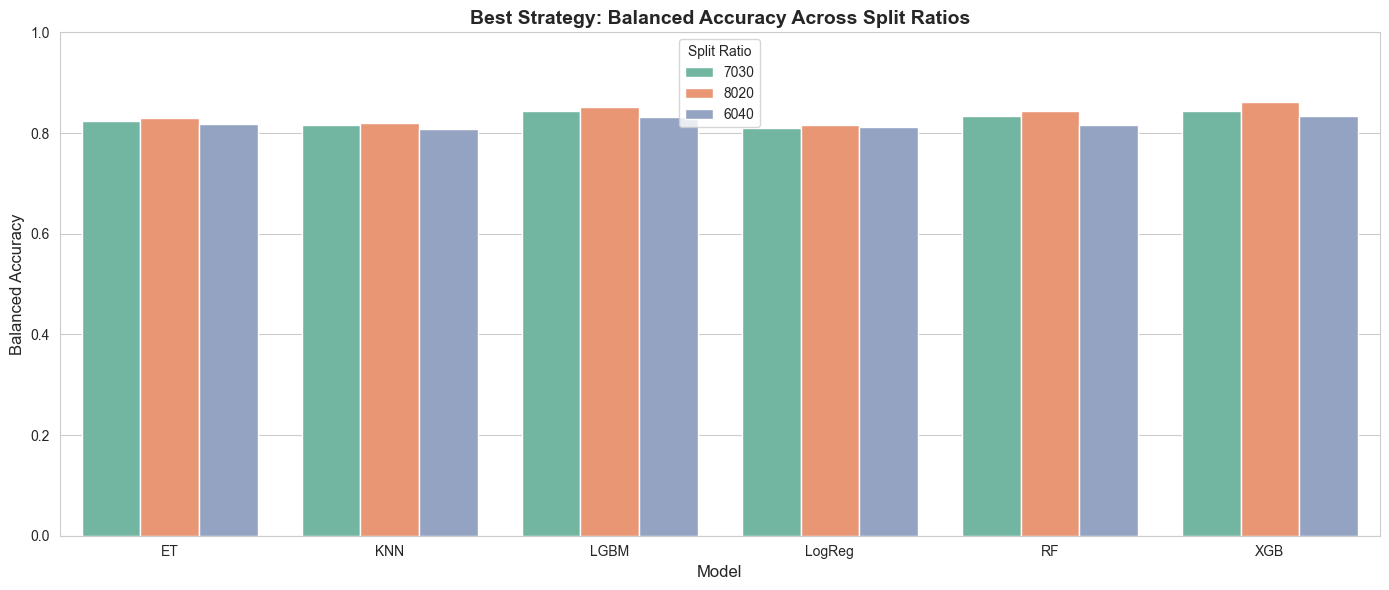


CHART 2: Sampling Strategy Comparison per Model (70/30 Split)


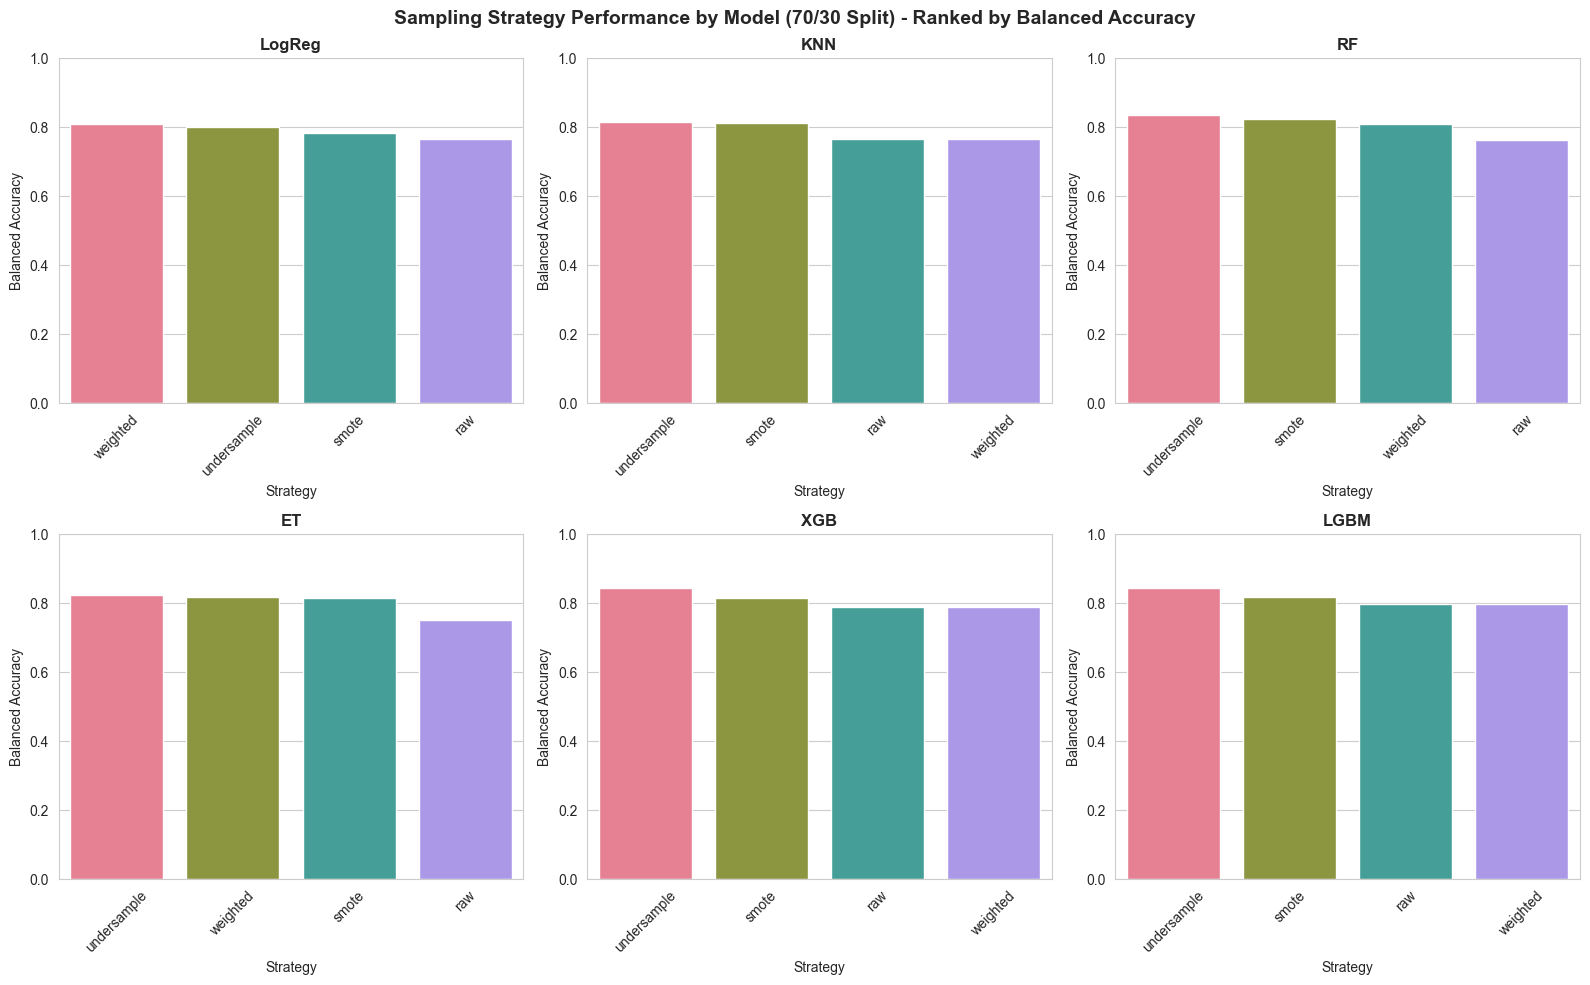


CHART 3: Stability Check - Mean ± Std Across Split Ratios (Best Strategies)


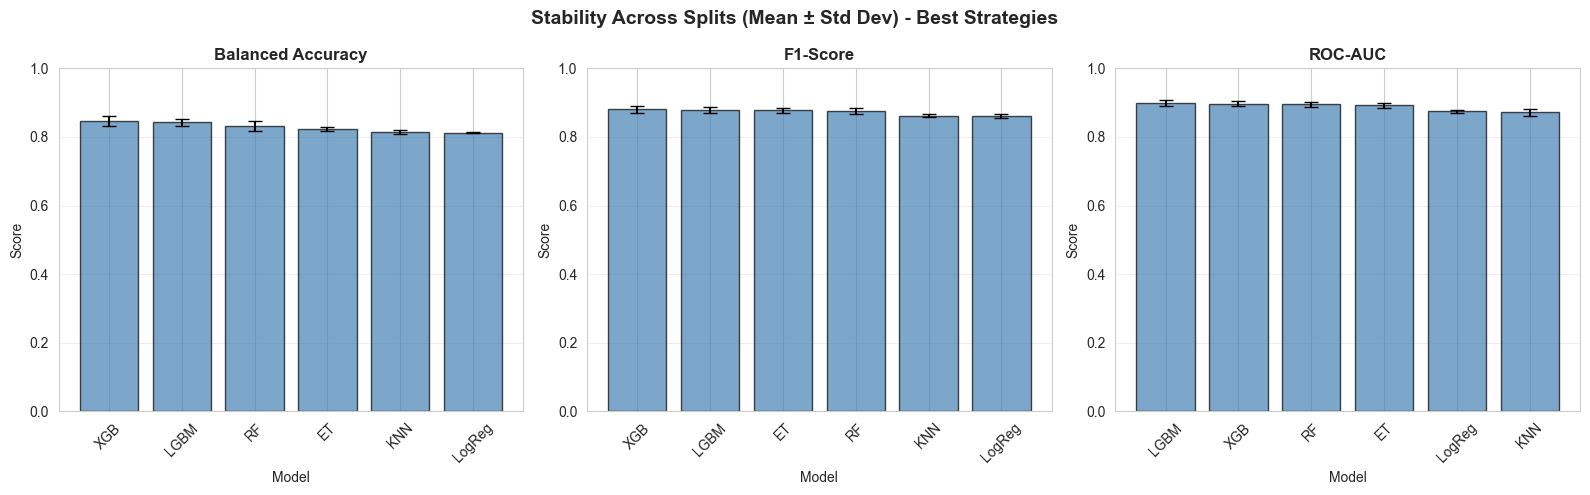


✓ All charts saved to ../figures/


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# ===== CHART 1: Best Strategy Performance Across All Splits =====
print("\n" + "="*100)
print("CHART 1: Best Strategy Accuracy Across Split Ratios")
print("="*100)

# Combine 70/30 best with other splits best
best_7030 = df_7030.loc[df_7030.groupby('model')['balanced_accuracy'].idxmax()].copy()
df_best_all = pd.concat([best_7030, df_other], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=df_best_all, x='model', y='balanced_accuracy', hue='split', ax=ax, palette='Set2')
ax.set_title('Best Strategy: Balanced Accuracy Across Split Ratios', fontsize=14, fontweight='bold')
ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(title='Split Ratio', fontsize=10)
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('../figures/chart_1_best_accuracy_across_splits.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== CHART 2: Sampling Strategy Comparison per Model (70/30) =====
print("\n" + "="*100)
print("CHART 2: Sampling Strategy Comparison per Model (70/30 Split)")
print("="*100)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Sampling Strategy Performance by Model (70/30 Split) - Ranked by Balanced Accuracy', 
             fontsize=14, fontweight='bold')

for idx, model_name in enumerate(['LogReg', 'KNN', 'RF', 'ET', 'XGB', 'LGBM']):
    ax = axes[idx // 3, idx % 3]
    model_data = df_7030[df_7030['model'] == model_name].sort_values('balanced_accuracy', ascending=False)
    
    sns.barplot(data=model_data, x='strategy', y='balanced_accuracy', ax=ax, palette='husl')
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Balanced Accuracy', fontsize=10)
    ax.set_xlabel('Strategy', fontsize=10)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/chart_2_strategies_per_model.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== CHART 3: Stability Across Splits with Error Bars =====
print("\n" + "="*100)
print("CHART 3: Stability Check - Mean ± Std Across Split Ratios (Best Strategies)")
print("="*100)

# Compute mean and std of best strategy across all 3 splits
stability_data = []
for model_name in ['LogReg', 'KNN', 'RF', 'ET', 'XGB', 'LGBM']:
    model_best_all = df_best_all[df_best_all['model'] == model_name]
    mean_ba = model_best_all['balanced_accuracy'].mean()
    std_ba = model_best_all['balanced_accuracy'].std()
    mean_f1 = model_best_all['f1'].mean()
    std_f1 = model_best_all['f1'].std()
    mean_roc = model_best_all['roc_auc'].mean()
    std_roc = model_best_all['roc_auc'].std()
    
    stability_data.append({
        'model': model_name,
        'metric': 'Balanced Accuracy',
        'mean': mean_ba,
        'std': std_ba
    })
    stability_data.append({
        'model': model_name,
        'metric': 'F1-Score',
        'mean': mean_f1,
        'std': std_f1
    })
    stability_data.append({
        'model': model_name,
        'metric': 'ROC-AUC',
        'mean': mean_roc,
        'std': std_roc
    })

df_stability = pd.DataFrame(stability_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Stability Across Splits (Mean ± Std Dev) - Best Strategies', 
             fontsize=14, fontweight='bold')

for idx, metric in enumerate(['Balanced Accuracy', 'F1-Score', 'ROC-AUC']):
    ax = axes[idx]
    metric_data = df_stability[df_stability['metric'] == metric].sort_values('mean', ascending=False)
    
    ax.bar(metric_data['model'], metric_data['mean'], yerr=metric_data['std'], 
           capsize=5, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/chart_3_stability_error_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All charts saved to ../figures/")
